In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, Optional, Dict, List
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
# The Bottleneck Problem

## Vanilla Encoder-Decoder Architecture

In a basic seq2seq model:
1. The **encoder** reads the entire input and compresses it into a fixed-size **context vector** (the final hidden state)
2. The **decoder** generates the output sequence using only this context vector

```
Encoder:  x1 → x2 → x3 → x4 → [context vector c]
Decoder:  c → y1 → y2 → y3
```

**The problem**: The context vector has a fixed dimension (e.g., 256), regardless of whether the input has 5 tokens or 500. For long sequences, this single vector cannot capture all the relevant information — it's a **bottleneck**.

**The solution (attention)**: Instead of forcing all information through one vector, let the decoder **look back** at all encoder hidden states at each decoding step, and dynamically decide which parts of the input to focus on.

---
# 1) Data Loading

```
Input:  "25 january 2003"  →  Output: "2003-01-25"
Input:  "march 5, 1998"    →  Output: "1998-03-05"
Input:  "01/12/2020"       →  Output: "2020-01-12"
```

This task is ideal because:
- It's deterministic (one correct answer per input)
- It requires **reordering** (the model must learn to rearrange year, month, day)
- It requires **alignment** (attention patterns are interpretable)
- No external data download needed

In [2]:
from datetime import datetime, timedelta

# Date format templates for input variety
INPUT_FORMATS = [
    "%d %B %Y",        # 25 January 2003
    "%B %d, %Y",       # January 25, 2003
    "%d/%m/%Y",        # 25/01/2003
    "%m/%d/%Y",        # 01/25/2003
    "%d %b %Y",        # 25 Jan 2003
    "%b %d, %Y",       # Jan 25, 2003
    "%Y/%m/%d",        # 2003/01/25
    "%d-%m-%Y",        # 25-01-2003
]

# Target format is always ISO 8601
OUTPUT_FORMAT = "%Y-%m-%d"


def generate_date_pairs(n: int = 10000) -> List[Tuple[str, str]]:
    """Generate (input_date_string, target_iso_string) pairs."""
    pairs = []
    start_date = datetime(1950, 1, 1)
    end_date = datetime(2030, 12, 31)
    total_days = (end_date - start_date).days

    for _ in range(n):
        # Random date
        date = start_date + timedelta(days=random.randint(0, total_days))

        # Random input format
        fmt = random.choice(INPUT_FORMATS)
        input_str = date.strftime(fmt).lower()

        # Standardized output
        output_str = date.strftime(OUTPUT_FORMAT)

        pairs.append((input_str, output_str))

    return pairs


pairs = generate_date_pairs(20000)
print("Sample date pairs:")
for inp, out in pairs[:8]:
    print(f"  '{inp}' → '{out}'")

Sample date pairs:
  'may 14, 2007' → '2007-05-14'
  '30 mar 1952' → '1952-03-30'
  '12/21/1971' → '1971-12-21'
  'july 09, 1962' → '1962-07-09'
  'september 17, 2010' → '2010-09-17'
  '2002/12/23' → '2002-12-23'
  '07 november 1952' → '1952-11-07'
  '05/29/1958' → '1958-05-29'


In [3]:
# Special tokens
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"


class CharVocab:
    """Character-level vocabulary with special tokens."""

    def __init__(self):
        self.char_to_idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}
        self.idx_to_char = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN}

    def build(self, texts: List[str]) -> "CharVocab":
        """Build vocabulary from all characters in texts."""
        chars = sorted(set(c for text in texts for c in text))
        for c in chars:
            if c not in self.char_to_idx:
                idx = len(self.char_to_idx)
                self.char_to_idx[c] = idx
                self.idx_to_char[idx] = c
        return self

    def encode(self, text: str, add_eos: bool = False) -> List[int]:
        indices = [self.char_to_idx[c] for c in text]
        if add_eos:
            indices.append(self.char_to_idx[EOS_TOKEN])
        return indices

    def decode(self, indices: List[int]) -> str:
        chars = []
        for idx in indices:
            c = self.idx_to_char[idx]
            if c == EOS_TOKEN:
                break
            if c not in (PAD_TOKEN, SOS_TOKEN):
                chars.append(c)
        return "".join(chars)

    def __len__(self) -> int:
        return len(self.char_to_idx)


# Build separate vocabularies for source and target
src_texts = [p[0] for p in pairs]
tgt_texts = [p[1] for p in pairs]

src_vocab = CharVocab().build(src_texts)
tgt_vocab = CharVocab().build(tgt_texts)

print(f"Source vocab size: {len(src_vocab)} — chars: {list(src_vocab.char_to_idx.keys())[3:]}")
print(f"Target vocab size: {len(tgt_vocab)} — chars: {list(tgt_vocab.char_to_idx.keys())[3:]}")

Source vocab size: 38 — chars: [' ', ',', '-', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y']
Target vocab size: 14 — chars: ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:
class DateDataset(Dataset):
    """Dataset for date format translation."""

    def __init__(
        self,
        pairs: List[Tuple[str, str]],
        src_vocab: CharVocab,
        tgt_vocab: CharVocab,
        max_src_len: int = 30,
        max_tgt_len: int = 12,
    ):
        self.src_data = []
        self.tgt_input = []  # Decoder input: <sos> + target[:-1]
        self.tgt_output = []  # Decoder target: target + <eos>

        sos_idx = tgt_vocab.char_to_idx[SOS_TOKEN]

        for src, tgt in pairs:
            src_enc = src_vocab.encode(src)
            tgt_enc = tgt_vocab.encode(tgt, add_eos=True)

            # Pad source
            src_padded = src_enc + [0] * (max_src_len - len(src_enc))

            # Decoder input: <sos> + target chars (no EOS)
            dec_input = [sos_idx] + tgt_enc[:-1]
            dec_input_padded = dec_input + [0] * (max_tgt_len - len(dec_input))

            # Decoder output: target chars + <eos>
            dec_output_padded = tgt_enc + [0] * (max_tgt_len - len(tgt_enc))

            self.src_data.append(torch.tensor(src_padded[:max_src_len], dtype=torch.long))
            self.tgt_input.append(torch.tensor(dec_input_padded[:max_tgt_len], dtype=torch.long))
            self.tgt_output.append(torch.tensor(dec_output_padded[:max_tgt_len], dtype=torch.long))

    def __len__(self) -> int:
        return len(self.src_data)

    def __getitem__(self, idx: int):
        return self.src_data[idx], self.tgt_input[idx], self.tgt_output[idx]


MAX_SRC_LEN = 25
MAX_TGT_LEN = 12  # "YYYY-MM-DD" + EOS = 11 chars

# Split 80/20
split = int(0.8 * len(pairs))
train_ds = DateDataset(pairs[:split], src_vocab, tgt_vocab, MAX_SRC_LEN, MAX_TGT_LEN)
test_ds = DateDataset(pairs[split:], src_vocab, tgt_vocab, MAX_SRC_LEN, MAX_TGT_LEN)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

# Verify one sample
s, ti, to = train_ds[0]
print(f"\nSource:         '{src_vocab.decode(s.tolist())}'")
print(f"Decoder input:  {[tgt_vocab.idx_to_char[i] for i in ti.tolist() if i != 0]}")
print(f"Decoder target: {[tgt_vocab.idx_to_char[i] for i in to.tolist() if i != 0]}")

Train: 16000, Test: 4000

Source:         'may 14, 2007'
Decoder input:  ['<sos>', '2', '0', '0', '7', '-', '0', '5', '-', '1', '4']
Decoder target: ['2', '0', '0', '7', '-', '0', '5', '-', '1', '4', '<eos>']


---
# 2) Bahdanau Attention (Additive Attention)

At each decoder timestep $t$, instead of using a fixed context vector, we compute a **weighted sum** of all encoder hidden states. The weights (attention scores) indicate how much each encoder position is relevant to the current decoding step.

**Bahdanau attention** (Bahdanau, Cho & Bengio, 2014) computes alignment scores using a small feedforward network:

$$e_{t,i} = v^T \tanh(W_s \cdot s_{t-1} + W_h \cdot h_i)$$
$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}$$
$$c_t = \sum_i \alpha_{t,i} \cdot h_i$$

Where:
- $s_{t-1}$: decoder hidden state at previous timestep — shape `(batch_num, hidden_dim)`
- $h_i$: encoder hidden state at position $i$ — shape `(batch_num, hidden_dim)`
- $\alpha_{t,i}$: attention weight (how much to attend to encoder position $i$)
- $c_t$: context vector (weighted combination of encoder states)

**Why "additive"?** Because $W_s \cdot s + W_h \cdot h$ adds two projections. This contrasts with **Luong (multiplicative/dot-product) attention** which computes $s^T W h$ or simply $s^T h$.

**Sample I/O:**

| Tensor | Shape |
|--------|-------|
| `encoder_outputs` | `(batch_num, src_seq_len, hidden_dim)` |
| `decoder_hidden` | `(batch_num, hidden_dim)` |
| `attention_weights` | `(batch_num, src_seq_len)` |
| `context_vector` | `(batch_num, hidden_dim)` |

In [5]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau (additive) attention mechanism.

    Computes attention weights over encoder outputs given a decoder state,
    then produces a context vector as the weighted sum.
    """

    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()

        # Project encoder hidden states
        # (batch_num, src_seq_len, encoder_dim) → (batch_num, src_seq_len, attention_dim)
        self.W_h = nn.Linear(encoder_dim, attention_dim, bias=False)

        # Project decoder hidden state
        # (batch_num, decoder_dim) → (batch_num, attention_dim)
        self.W_s = nn.Linear(decoder_dim, attention_dim, bias=False)

        # Produce scalar energy score
        # (batch_num, src_seq_len, attention_dim) → (batch_num, src_seq_len, 1)
        self.v = nn.Linear(attention_dim, 1, bias=False)

    def forward(
        self,
        encoder_outputs: torch.Tensor,
        decoder_hidden: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            encoder_outputs: (batch_num, src_seq_len, encoder_dim)
            decoder_hidden: (batch_num, decoder_dim)
        Returns:
            context: (batch_num, encoder_dim)
            weights: (batch_num, src_seq_len)
        """
        # Project encoder outputs (can be precomputed for efficiency)
        # (batch_num, src_seq_len, attention_dim)
        encoder_proj = self.W_h(encoder_outputs)

        # Project decoder hidden and broadcast across source positions
        # (batch_num, decoder_dim) → (batch_num, attention_dim) → (batch_num, 1, attention_dim)
        decoder_proj = self.W_s(decoder_hidden).unsqueeze(1)

        # Additive attention: sum projections, apply tanh, then v
        # (batch_num, src_seq_len, attention_dim) → (batch_num, src_seq_len, 1)
        energy = self.v(torch.tanh(encoder_proj + decoder_proj))

        # Squeeze and normalize to get attention weights
        # (batch_num, src_seq_len)
        weights = F.softmax(energy.squeeze(-1), dim=1)

        # Weighted sum of encoder outputs
        # (batch_num, 1, src_seq_len) @ (batch_num, src_seq_len, encoder_dim)
        # → (batch_num, 1, encoder_dim) → (batch_num, encoder_dim)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, weights


# Quick shape verification
attn = BahdanauAttention(encoder_dim=64, decoder_dim=64, attention_dim=32)
enc_out = torch.randn(4, 20, 64)  # (batch_num, src_seq_len, encoder_dim)
dec_h = torch.randn(4, 64)        # (batch_num, decoder_dim)
ctx, wts = attn(enc_out, dec_h)
print(f"Context: {ctx.shape}  # (batch_num, encoder_dim)")
print(f"Weights: {wts.shape}  # (batch_num, src_seq_len)")
print(f"Weights sum: {wts[0].sum().item():.4f} (should be 1.0)")

Context: torch.Size([4, 64])  # (batch_num, encoder_dim)
Weights: torch.Size([4, 20])  # (batch_num, src_seq_len)
Weights sum: 1.0000 (should be 1.0)


---
# 3) Architecture

```
                    ┌─────────────────────┐
 Input chars ─────►│    Encoder LSTM      │──── encoder_outputs (all h_t)
                    └─────────────────────┘              │
                                                         ▼
                    ┌─────────────────────┐    ┌──────────────────┐
 <sos>, y1, y2 ───►│    Decoder LSTM      │◄───│ Bahdanau Attn    │
                    └──────────┬──────────┘    └──────────────────┘
                               │
                    ┌──────────▼──────────┐
                    │   Linear + Softmax   │──── predicted chars
                    └─────────────────────┘
```

At each decoder timestep:
1. Compute attention weights over all encoder outputs using current decoder hidden state
2. Compute context vector as weighted sum of encoder outputs
3. Concatenate context vector with current decoder input embedding
4. Feed through decoder LSTM
5. Project to vocabulary and predict next token

In [6]:
class Encoder(nn.Module):
    """Bidirectional LSTM encoder."""

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        # (batch_num, src_seq_len) → (batch_num, src_seq_len, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional: output dim is 2 * hidden_dim
        # (batch_num, src_seq_len, embed_dim) → (batch_num, src_seq_len, hidden_dim * 2)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, batch_first=True, bidirectional=True
        )

        # Project bidirectional output to hidden_dim for decoder compatibility
        # (batch_num, src_seq_len, hidden_dim * 2) → (batch_num, src_seq_len, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Args:
            src: (batch_num, src_seq_len)
        Returns:
            outputs: (batch_num, src_seq_len, hidden_dim)
            (h_n, c_n): each (1, batch_num, hidden_dim) — for decoder init
        """
        # (batch_num, src_seq_len, embed_dim)
        embedded = self.dropout(self.embedding(src))

        # (batch_num, src_seq_len, hidden_dim * 2)
        outputs, (h_n, c_n) = self.lstm(embedded)

        # Project to decoder dimension
        # (batch_num, src_seq_len, hidden_dim)
        outputs = torch.tanh(self.fc(outputs))

        # Combine bidirectional hidden states for decoder initialization
        # h_n: (2, batch_num, hidden_dim) → (1, batch_num, hidden_dim)
        h_n = torch.tanh(self.fc(torch.cat([h_n[0], h_n[1]], dim=1))).unsqueeze(0)
        c_n = torch.tanh(self.fc(torch.cat([c_n[0], c_n[1]], dim=1))).unsqueeze(0)

        return outputs, (h_n, c_n)

In [7]:
class AttentionDecoder(nn.Module):
    """
    LSTM decoder with Bahdanau attention.

    At each timestep:
    1. Compute attention over encoder outputs using current decoder state
    2. Concatenate context vector with input embedding
    3. Feed through LSTM
    4. Predict next token
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        attention_dim: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim

        # (batch_num,) → (batch_num, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Attention module
        self.attention = BahdanauAttention(hidden_dim, hidden_dim, attention_dim)

        # LSTM input: embedding + context vector
        # (batch_num, embed_dim + hidden_dim) → (batch_num, hidden_dim)
        self.lstm = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=True)

        # Output projection
        # (batch_num, hidden_dim + hidden_dim + embed_dim) → (batch_num, vocab_size)
        self.fc = nn.Linear(hidden_dim + hidden_dim + embed_dim, vocab_size)

        self.dropout = nn.Dropout(dropout)

    def forward_step(
        self,
        input_token: torch.Tensor,
        hidden: Tuple[torch.Tensor, torch.Tensor],
        encoder_outputs: torch.Tensor,
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        """
        Single decoder timestep.

        Args:
            input_token: (batch_num,) — current input token index
            hidden: (h, c) each (1, batch_num, hidden_dim)
            encoder_outputs: (batch_num, src_seq_len, hidden_dim)
        Returns:
            prediction: (batch_num, vocab_size)
            hidden: updated (h, c)
            attn_weights: (batch_num, src_seq_len)
        """
        # Embed current token
        # (batch_num,) → (batch_num, embed_dim)
        embedded = self.dropout(self.embedding(input_token))

        # Compute attention using decoder hidden state h
        # h: (1, batch_num, hidden_dim) → (batch_num, hidden_dim)
        h_squeezed = hidden[0].squeeze(0)

        # context: (batch_num, hidden_dim), weights: (batch_num, src_seq_len)
        context, attn_weights = self.attention(encoder_outputs, h_squeezed)

        # Concatenate embedding and context as LSTM input
        # (batch_num, embed_dim + hidden_dim) → (batch_num, 1, embed_dim + hidden_dim)
        lstm_input = torch.cat([embedded, context], dim=1).unsqueeze(1)

        # One LSTM step
        # (batch_num, 1, hidden_dim)
        lstm_out, hidden = self.lstm(lstm_input, hidden)

        # Predict next token: concatenate lstm output, context, and embedding
        # This "skip connection" style helps gradient flow
        # (batch_num, hidden_dim + hidden_dim + embed_dim)
        combined = torch.cat([lstm_out.squeeze(1), context, embedded], dim=1)

        # (batch_num, vocab_size)
        prediction = self.fc(self.dropout(combined))

        return prediction, hidden, attn_weights

In [8]:
class Seq2SeqAttention(nn.Module):
    """
    Full sequence-to-sequence model with Bahdanau attention.

    Supports teacher forcing during training:
      - With probability `teacher_forcing_ratio`, feed ground-truth token as next input
      - Otherwise, feed the model's own prediction (autoregressive)
    """

    def __init__(self, encoder: Encoder, decoder: AttentionDecoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src: torch.Tensor,
        tgt_input: torch.Tensor,
        teacher_forcing_ratio: float = 0.5,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            src: (batch_num, src_seq_len)
            tgt_input: (batch_num, tgt_seq_len) — starts with <sos>
            teacher_forcing_ratio: probability of using ground-truth input
        Returns:
            outputs: (batch_num, tgt_seq_len, tgt_vocab_size)
            attention_weights: (batch_num, tgt_seq_len, src_seq_len)
        """
        batch_num = src.size(0)
        tgt_seq_len = tgt_input.size(1)
        tgt_vocab_size = self.decoder.fc.out_features
        src_seq_len = src.size(1)

        # Encode source sequence
        # encoder_outputs: (batch_num, src_seq_len, hidden_dim)
        encoder_outputs, hidden = self.encoder(src)

        # Storage for decoder outputs and attention
        all_outputs = torch.zeros(batch_num, tgt_seq_len, tgt_vocab_size, device=src.device)
        all_attention = torch.zeros(batch_num, tgt_seq_len, src_seq_len, device=src.device)

        # First decoder input is <sos>
        # (batch_num,)
        current_input = tgt_input[:, 0]

        for t in range(tgt_seq_len):
            # One decoder step
            prediction, hidden, attn_weights = self.decoder.forward_step(
                current_input, hidden, encoder_outputs
            )

            all_outputs[:, t] = prediction
            all_attention[:, t] = attn_weights

            # Teacher forcing: use ground truth or model's prediction
            use_teacher = random.random() < teacher_forcing_ratio
            if use_teacher and t + 1 < tgt_seq_len:
                current_input = tgt_input[:, t + 1]
            else:
                current_input = prediction.argmax(dim=1)

        return all_outputs, all_attention

In [9]:
# Hyperparameters
EMBED_DIM = 32
HIDDEN_DIM = 128
ATTENTION_DIM = 64
DROPOUT = 0.1
LR = 1e-3
NUM_EPOCHS = 15
CLIP_NORM = 1.0

# Build model
encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT)
decoder = AttentionDecoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, ATTENTION_DIM, DROPOUT)
model = Seq2SeqAttention(encoder, decoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Total parameters: 369,422


In [10]:
def compute_accuracy(outputs: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute full-sequence accuracy (entire date must match).

    Args:
        outputs: (batch_num, tgt_seq_len, vocab_size)
        targets: (batch_num, tgt_seq_len)
    """
    # (batch_num, tgt_seq_len)
    preds = outputs.argmax(dim=-1)

    # Mask padding positions
    mask = targets != 0

    # A sequence is correct only if ALL non-padding positions match
    correct_tokens = (preds == targets) | ~mask
    # (batch_num,) — True if all positions correct
    correct_seqs = correct_tokens.all(dim=1)

    return correct_seqs.float().mean().item()


# Training loop
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    # Decay teacher forcing over epochs
    tf_ratio = max(0.1, 1.0 - epoch / NUM_EPOCHS)

    # Train
    model.train()
    epoch_loss, epoch_acc, n_batches = 0.0, 0.0, 0

    for src_batch, tgt_in_batch, tgt_out_batch in train_loader:
        src_batch = src_batch.to(device)
        tgt_in_batch = tgt_in_batch.to(device)
        tgt_out_batch = tgt_out_batch.to(device)

        # (batch_num, tgt_seq_len, vocab_size)
        outputs, _ = model(src_batch, tgt_in_batch, teacher_forcing_ratio=tf_ratio)

        # Reshape for cross-entropy
        loss = criterion(
            outputs.view(-1, outputs.size(-1)),
            tgt_out_batch.view(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += compute_accuracy(outputs, tgt_out_batch)
        n_batches += 1

    train_loss = epoch_loss / n_batches
    train_acc = epoch_acc / n_batches

    # Evaluate (no teacher forcing)
    model.eval()
    test_loss, test_acc, n_test = 0.0, 0.0, 0
    with torch.no_grad():
        for src_batch, tgt_in_batch, tgt_out_batch in test_loader:
            src_batch = src_batch.to(device)
            tgt_in_batch = tgt_in_batch.to(device)
            tgt_out_batch = tgt_out_batch.to(device)

            outputs, _ = model(src_batch, tgt_in_batch, teacher_forcing_ratio=0.0)
            loss = criterion(
                outputs.view(-1, outputs.size(-1)),
                tgt_out_batch.view(-1),
            )

            test_loss += loss.item()
            test_acc += compute_accuracy(outputs, tgt_out_batch)
            n_test += 1

    test_loss /= n_test
    test_acc /= n_test

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | TF={tf_ratio:.2f} | "
        f"Train: loss={train_loss:.4f} acc={train_acc:.4f} | "
        f"Test: loss={test_loss:.4f} acc={test_acc:.4f}"
    )

Epoch  1/15 | TF=0.93 | Train: loss=1.2896 acc=0.0017 | Test: loss=0.7325 acc=0.0166
Epoch  2/15 | TF=0.87 | Train: loss=0.3787 acc=0.2888 | Test: loss=0.1035 acc=0.8770
Epoch  3/15 | TF=0.80 | Train: loss=0.0512 acc=0.9062 | Test: loss=0.0388 acc=0.9529
Epoch  4/15 | TF=0.73 | Train: loss=0.0247 acc=0.9437 | Test: loss=0.0340 acc=0.9521
Epoch  5/15 | TF=0.67 | Train: loss=0.0210 acc=0.9493 | Test: loss=0.0319 acc=0.9529
Epoch  6/15 | TF=0.60 | Train: loss=0.0188 acc=0.9504 | Test: loss=0.0251 acc=0.9492
Epoch  7/15 | TF=0.53 | Train: loss=0.0181 acc=0.9487 | Test: loss=0.0228 acc=0.9502
Epoch  8/15 | TF=0.47 | Train: loss=0.0167 acc=0.9491 | Test: loss=0.0243 acc=0.9536
Epoch  9/15 | TF=0.40 | Train: loss=0.0169 acc=0.9507 | Test: loss=0.0228 acc=0.9495
Epoch 10/15 | TF=0.33 | Train: loss=0.0164 acc=0.9501 | Test: loss=0.0202 acc=0.9553
Epoch 11/15 | TF=0.27 | Train: loss=0.0187 acc=0.9430 | Test: loss=0.0188 acc=0.9507
Epoch 12/15 | TF=0.20 | Train: loss=0.0177 acc=0.9461 | Test: los

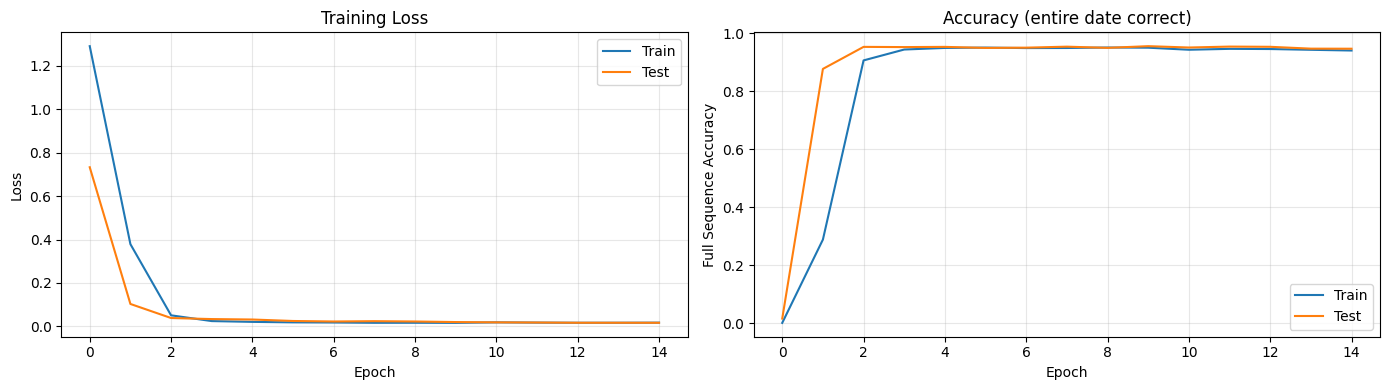

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["test_acc"], label="Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Full Sequence Accuracy")
axes[1].set_title("Accuracy (entire date correct)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 5) Visualization

One of the most powerful properties of attention is **interpretability**. By visualizing the attention weights, we can see exactly which input characters the decoder is focusing on when producing each output character.

For our date translation task, we expect to see:
- When producing the year digits, attention focuses on the year portion of the input
- When producing the month digits, attention focuses on the month name/number
- When producing the day digits, attention focuses on the day number

In [12]:
@torch.no_grad()
def translate_and_attend(
    model: Seq2SeqAttention,
    src_text: str,
    src_vocab: CharVocab,
    tgt_vocab: CharVocab,
    max_len: int = MAX_TGT_LEN,
) -> Tuple[str, np.ndarray, str]:
    """
    Translate a single source string and return attention weights.

    Returns:
        prediction: decoded string
        attention: (tgt_len, src_len) numpy array
        src_chars: source characters for axis labels
    """
    model.eval()

    # Encode source
    src_enc = src_vocab.encode(src_text)
    src_padded = src_enc + [0] * (MAX_SRC_LEN - len(src_enc))
    # (1, src_seq_len)
    src_tensor = torch.tensor([src_padded[:MAX_SRC_LEN]], device=device)

    # Encode
    encoder_outputs, hidden = model.encoder(src_tensor)

    # Decode autoregressively
    sos_idx = tgt_vocab.char_to_idx[SOS_TOKEN]
    eos_idx = tgt_vocab.char_to_idx[EOS_TOKEN]
    current_input = torch.tensor([sos_idx], device=device)

    predicted_indices = []
    attention_weights = []

    for _ in range(max_len):
        prediction, hidden, attn_w = model.decoder.forward_step(
            current_input, hidden, encoder_outputs
        )
        attention_weights.append(attn_w.cpu().numpy()[0])

        next_idx = prediction.argmax(dim=1).item()
        if next_idx == eos_idx:
            break
        predicted_indices.append(next_idx)
        current_input = torch.tensor([next_idx], device=device)

    pred_text = tgt_vocab.decode(predicted_indices)
    attn_matrix = np.array(attention_weights)  # (tgt_steps, src_seq_len)

    return pred_text, attn_matrix, src_text


def plot_attention(
    src_text: str,
    pred_text: str,
    attention: np.ndarray,
    title: str = "",
):
    """Plot attention heatmap between source and target characters."""
    src_chars = list(src_text)
    tgt_chars = list(pred_text)

    # Trim attention to actual source length
    src_len = len(src_chars)
    tgt_len = len(tgt_chars)
    attn = attention[:tgt_len, :src_len]

    fig, ax = plt.subplots(figsize=(max(8, src_len * 0.4), max(4, tgt_len * 0.4)))
    cax = ax.matshow(attn, cmap="viridis", aspect="auto")
    fig.colorbar(cax, ax=ax, fraction=0.046)

    ax.set_xticks(range(src_len))
    ax.set_xticklabels(src_chars, fontsize=10)
    ax.set_yticks(range(tgt_len))
    ax.set_yticklabels(tgt_chars, fontsize=10)

    ax.set_xlabel("Source (input date)")
    ax.set_ylabel("Target (ISO output)")
    ax.set_title(title or f"'{src_text}' → '{pred_text}'")

    plt.tight_layout()
    plt.show()

Predictions:
  '25 january 2003' → '2003-01-25'
  'march 5, 1998' → '1998-03-05'
  '12/06/2015' → '2015-12-06'
  'july 4, 1776' → '1767-07-44'
  '2023/11/30' → '2023-11-30'


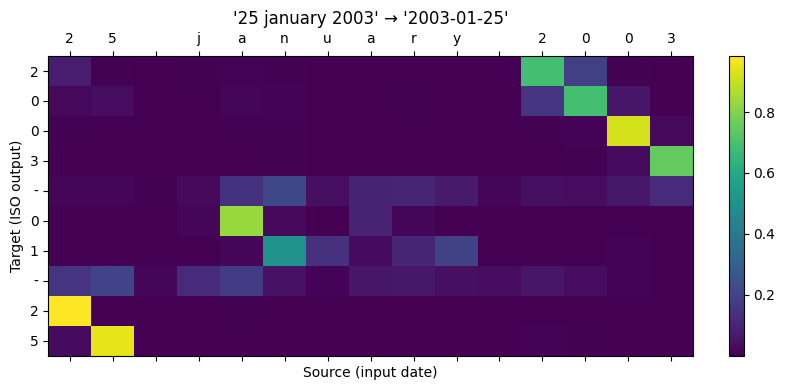

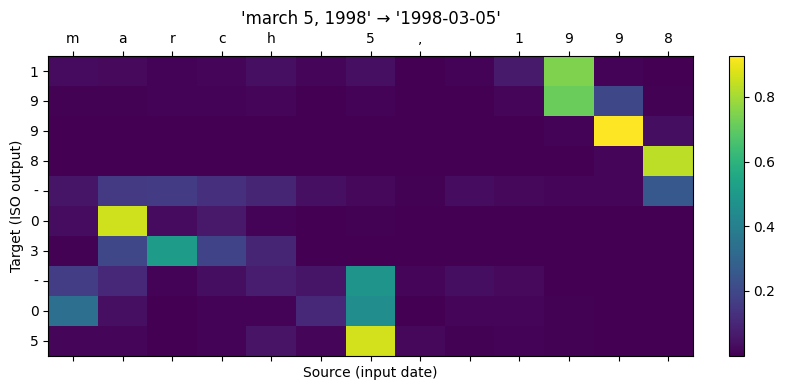

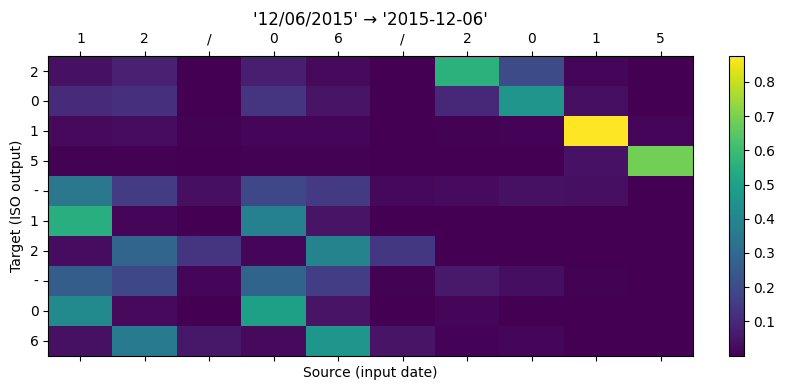

In [13]:
# Visualize attention on several examples
test_examples = [
    "25 january 2003",
    "march 5, 1998",
    "12/06/2015",
    "july 4, 1776",
    "2023/11/30",
]

print("Predictions:")
for src in test_examples:
    pred, attn, _ = translate_and_attend(model, src, src_vocab, tgt_vocab)
    print(f"  '{src}' → '{pred}'")

# Detailed attention plots for two examples
for src in test_examples[:3]:
    pred, attn, _ = translate_and_attend(model, src, src_vocab, tgt_vocab)
    plot_attention(src, pred, attn)

---
# Summary

### Core concepts
- The **bottleneck problem** in vanilla encoder-decoder: compressing all source info into a fixed-size vector fails for long sequences
- **Attention** solves this by letting the decoder access all encoder hidden states dynamically
- **Teacher forcing** accelerates training but creates exposure bias (model never sees its own errors during training). Scheduled sampling (decaying TF ratio) partially mitigates this.

### The evolutionary path
```
RNN (1990s)
  → LSTM/GRU (1997/2014) — solved vanishing gradients
    → Seq2Seq (2014) — encoder-decoder for sequence transduction  
      → Attention (2015) — solved the bottleneck problem
        → Transformer (2017) — removed the RNN entirely, using only attention
          → GPT, BERT, etc. — scaled Transformers to billions of parameters
```

**When to Still Use RNNs**:

Despite Transformers dominating most NLP benchmarks, RNNs remain relevant in specific scenarios:

1. **Extremely long sequences with limited memory**: RNNs process one token at a time with $O(1)$ memory per step, while Transformers need $O(n^2)$ for the attention matrix. State-space models (Mamba, S4) are the modern evolution of this idea.

2. **Streaming / online inference**: RNNs naturally process input incrementally. Transformers need the full sequence (or windowed approaches like Sliding Window Attention).

3. **Edge devices with limited compute**: Small LSTMs can be very efficient for tasks like keyword spotting or simple time-series prediction.

4. **Time-series with strong temporal structure**: Tasks where the sequential inductive bias of RNNs is genuinely helpful (e.g., control systems, some financial applications).

5. **As components within larger architectures**: RWKV and similar models combine RNN-like inference efficiency with Transformer-like training parallelism.